**NAME: EMMANUEL BRIGHT CHETACHI**

**Position: Data Analysis Intern**

**Task Duration:  24/08/2026 –  24/09/2026**

**ID :- CV/A1/87703**

**PROJECT TITLE: SENTIMENT ANALYSIS**

**DATASET OF INTEREST: SENTIIMENT DATASET**


In [65]:
# conecting my googledrive to my colab
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# importing required Packages
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [67]:
# importing dataset of interest
file_path = "/content/drive/MyDrive/Copy of 3) Sentiment dataset.csv"
df = pd.read_csv(file_path)


 ## PROJECT 1

 ## TASK 1

In [68]:
# UPLOADING OUR DATASET TO OUR ENVIRONMENT AND INSPECTING
def dataset_upload(file_path):
  df = pd.read_csv(file_path)
  print('>>>DATASET UPLOADED SUCCESSFULLY<<<')
  print(f">>>original dataset is shown below<<<")
  display (df.head(5))
  print(f">>>CHECKING DATASET INFORMATION<<<")
  display(df.info())
  print (f">>>Here is the size of our dataset, {df.shape}<<<")


In [69]:
dataset_upload(file_path)

>>>DATASET UPLOADED SUCCESSFULLY<<<
>>>original dataset is shown below<<<


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


>>>CHECKING DATASET INFORMATION<<<
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


None

>>>Here is the size of our dataset, (732, 15)<<<


In [70]:
# IDENTIFYING MISSING VALUES
print(f"<<<CHECKING FOR MISSING VALUES>>>")
missing_values = df.isnull().sum()
print(missing_values)


<<<CHECKING FOR MISSING VALUES>>>
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [71]:
# droping rows where sentiment lable or text is missing
df = df.dropna(subset=['Text', 'Sentiment'])
df.shape

(732, 15)

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
# REMOVING DUPLICATED ROWS
original_rows = len(df)
df = df.drop_duplicates(subset=['Text'])
print(f'Removed {original_rows - len(df)} duplicate text entries.')

Removed 25 duplicate text entries.


In [74]:
df.shape

(707, 15)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 707 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  707 non-null    int64  
 1   Unnamed: 0    707 non-null    int64  
 2   Text          707 non-null    object 
 3   Sentiment     707 non-null    object 
 4   Timestamp     707 non-null    object 
 5   User          707 non-null    object 
 6   Platform      707 non-null    object 
 7   Hashtags      707 non-null    object 
 8   Retweets      707 non-null    float64
 9   Likes         707 non-null    float64
 10  Country       707 non-null    object 
 11  Year          707 non-null    int64  
 12  Month         707 non-null    int64  
 13  Day           707 non-null    int64  
 14  Hour          707 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 88.4+ KB


In [76]:
# text cleaning
def clean_text(Text):
  Text = str(Text).lower()
  print ('>>>removing URLs<<<')
  Text=re.sub(r'http\S+|https\S+', '', Text, flags=re.MULTILINE)
  print ('>>>Removing HTML tags incase presecnt<<<')
  Text = re.sub(r'<.*?>', '', Text)
  print ('>>>removing special characters<<<')
  Text = re.sub(r'[^a-zA-Z\s]', '', Text)
  print ('>>>removing extra whitespaces<<<')
  return Text

In [77]:
df['clean_text'] = df['Text'].apply(clean_text)

>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removing extra whitespaces<<<
>>>removing URLs<<<
>>>Removing HTML tags incase presecnt<<<
>>>removing special characters<<<
>>>removi

In [78]:
# standardizing categorical sentiment labels
print (">>>standardizing categorical sentiment labels<<<")
df['Sentiment'] = df['Sentiment'].astype(str).str.lower().str.strip()
print('>>>cleaned Data Preview<<<')
display (df[['Text', 'clean_text', 'Sentiment']].head())


>>>standardizing categorical sentiment labels<<<
>>>cleaned Data Preview<<<


,Text,clean_text,Sentiment
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park ...,positive
1,Traffic was terrible this morning. ...,traffic was terrible this morning ...,negative
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout,positive
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway ...,positive
4,Trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight ...,neutral


In [79]:
# saving the preprocessed data
df.to_csv('cleaned_sentiment_data.csv', index=False)
print ('\npreprocesses text dataset saved successfully as'
" 'clean_sentiment_data.csv'.")



preprocesses text dataset saved successfully as 'clean_sentiment_data.csv'.


## Task two

In [80]:
# loading the cleaned dataset and inspection

df = pd.read_csv('cleaned_sentiment_data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,clean_text
0,0,0,Enjoying a beautiful day at the park! ...,positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying a beautiful day at the park ...
1,1,1,Traffic was terrible this morning. ...,negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic was terrible this morning ...
2,2,2,Just finished an amazing workout! 💪 ...,positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,just finished an amazing workout
3,3,3,Excited about the upcoming weekend getaway! ...,positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited about the upcoming weekend getaway ...
4,4,4,Trying out a new recipe for dinner tonight. ...,neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying out a new recipe for dinner tonight ...


In [81]:
# Calculating the Summary Statistics (mean, median, mode, standard deviation)
print('>>>Summary Statistics (Numerical Features)<<<')
print(df.describe())

>>>Summary Statistics (Numerical Features)<<<
       Unnamed: 0.1  Unnamed: 0    Retweets       Likes         Year  \
count    707.000000  707.000000  707.000000  707.000000   707.000000   
mean     368.404526  371.654880   21.567185   43.016973  2020.480905   
std      214.813729  215.753275    7.126891   14.221527     2.830553   
min        0.000000    0.000000    5.000000   10.000000  2010.000000   
25%      177.500000  179.500000   18.000000   35.000000  2019.000000   
50%      375.000000  379.000000   22.000000   43.000000  2021.000000   
75%      555.500000  559.500000   25.000000   50.000000  2023.000000   
max      732.000000  736.000000   40.000000   80.000000  2023.000000   

            Month         Day        Hour  
count  707.000000  707.000000  707.000000  
mean     6.103253   15.541726   15.626591  
std      3.406680    8.450281    4.050919  
min      1.000000    1.000000    0.000000  
25%      3.000000   10.000000   13.000000  
50%      6.000000   15.000000   16.000000

In [82]:
# getting the mode
print('>>>Mode (Checking for the Most Frequent Values)<<<')
print(df.mode().iloc[0])

>>>Mode (Checking for the Most Frequent Values)<<<
Unnamed: 0.1                                                    0
Unnamed: 0                                                      0
Text             A bitter experience turned into a valuable le...
Sentiment                                                positive
Timestamp                                     2019-04-05 17:30:00
User                                       ArchaeologyEnthusiast 
Platform                                               Instagram 
Hashtags              #Acceptance #LifeJourney                   
Retweets                                                     22.0
Likes                                                        45.0
Country                                                       USA
Year                                                       2023.0
Month                                                         2.0
Day                                                          15.0
Hour                     

### Visualize Data Distributions

In [83]:

# Set general plot style
sns.set_theme(style='whitegrid')

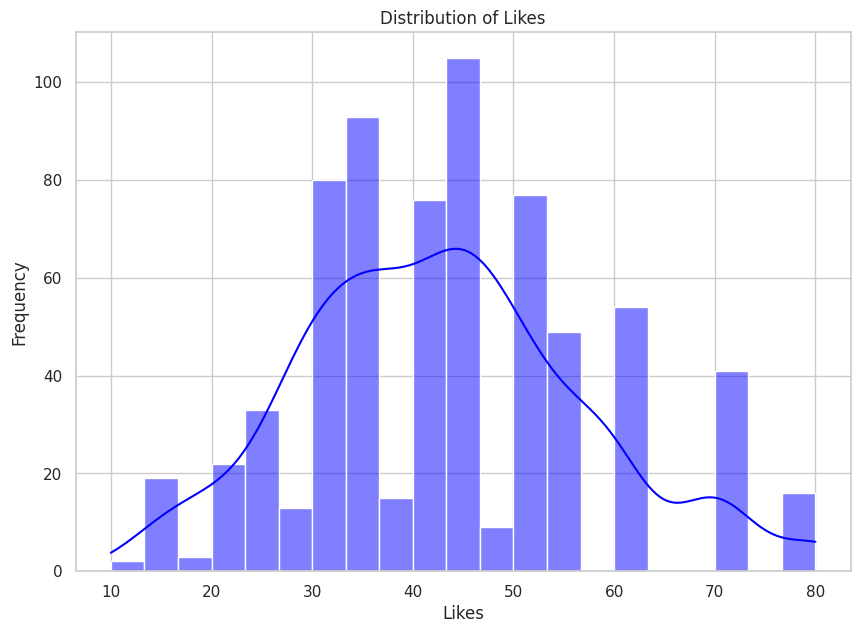

In [84]:
# figure 1 shows a Histplot(histogram) of Likes

plt.figure(figsize=(10, 7))
sns.histplot(df['Likes'], kde=True, color='blue')
plt.title('Distribution of Likes')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_787/2273391879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Likes', data=df, palette='Set2')


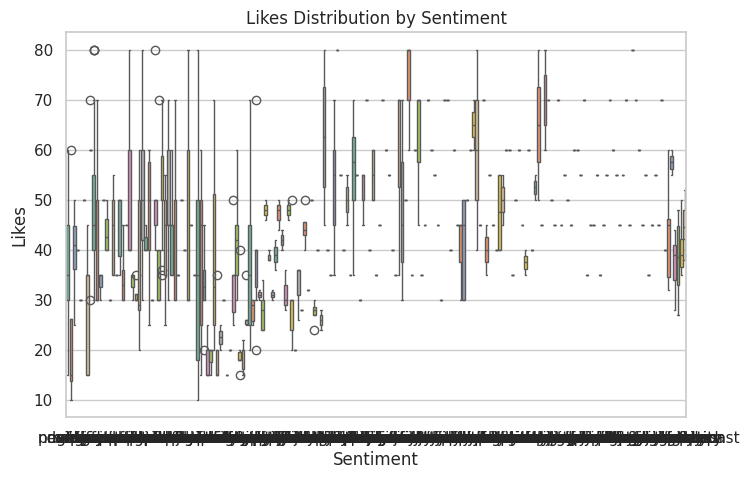

In [85]:
# Figure 2  shows Boxplot of Likes across Sentiments
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sentiment', y='Likes', data=df, palette='Set2')
plt.title('Likes Distribution by Sentiment')
plt.show()

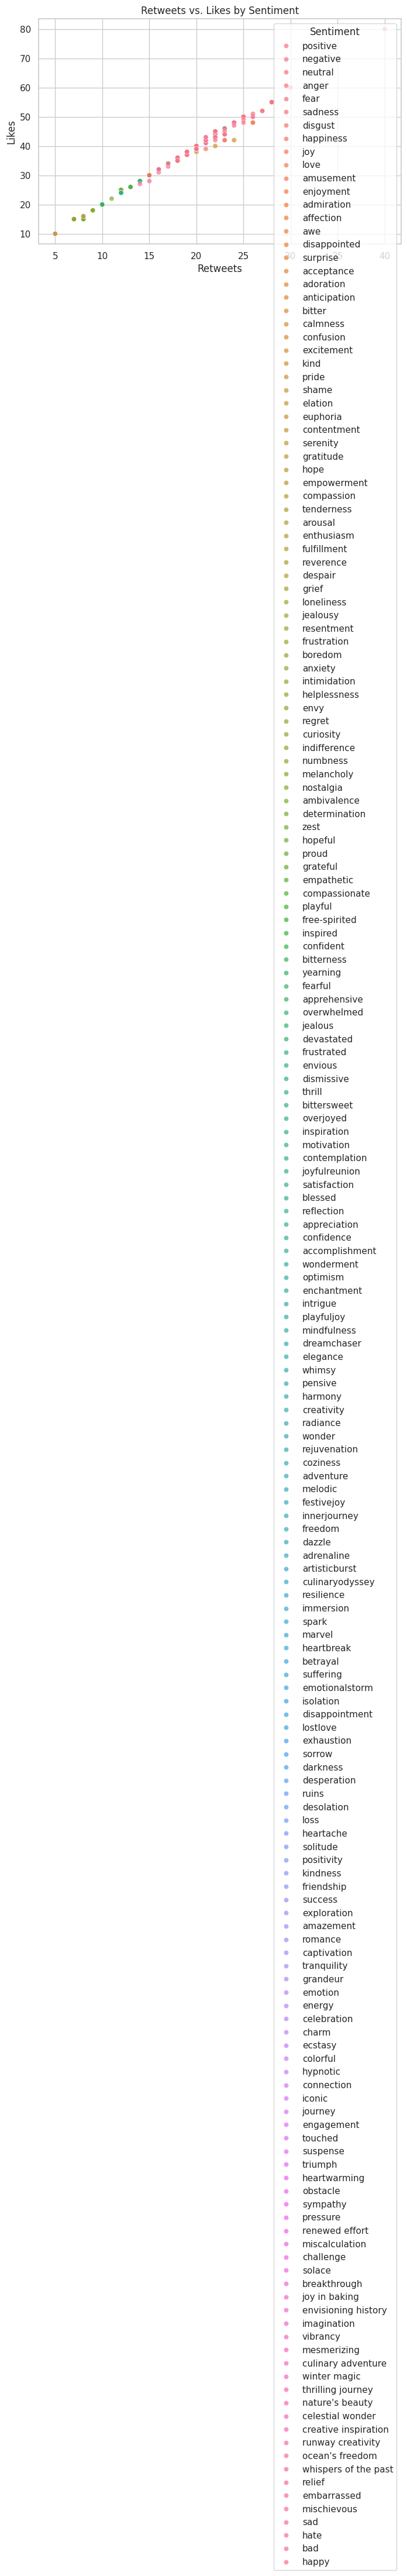

In [86]:
# Figure 3 shows Scatter Plot between Retweets and Likes
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Retweets', y='Likes', hue='Sentiment', data=df, alpha=0.7
)
plt.title('Retweets vs. Likes by Sentiment')
plt.xlabel('Retweets')
plt.ylabel('Likes')
plt.show()

### Find Correlations Between Numerical Features

In [87]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

print('\n--- Correlation Matrix ---')
correlation_matrix = numerical_df.corr()
print(correlation_matrix)


--- Correlation Matrix ---
              Unnamed: 0.1  Unnamed: 0  Retweets     Likes      Year  \
Unnamed: 0.1      1.000000    0.999995  0.388927  0.376434  0.103678   
Unnamed: 0        0.999995    1.000000  0.389202  0.376726  0.102843   
Retweets          0.388927    0.389202  1.000000  0.998468 -0.033832   
Likes             0.376434    0.376726  0.998468  1.000000 -0.037290   
Year              0.103678    0.102843 -0.033832 -0.037290  1.000000   
Month             0.452565    0.453043  0.079785  0.072995 -0.315389   
Day              -0.085176   -0.085527  0.009802  0.012087  0.033151   
Hour              0.325283    0.325180  0.193633  0.191884 -0.089440   

                 Month       Day      Hour  
Unnamed: 0.1  0.452565 -0.085176  0.325283  
Unnamed: 0    0.453043 -0.085527  0.325180  
Retweets      0.079785  0.009802  0.193633  
Likes         0.072995  0.012087  0.191884  
Year         -0.315389  0.033151 -0.089440  
Month         1.000000 -0.156198  0.139923  
Day     

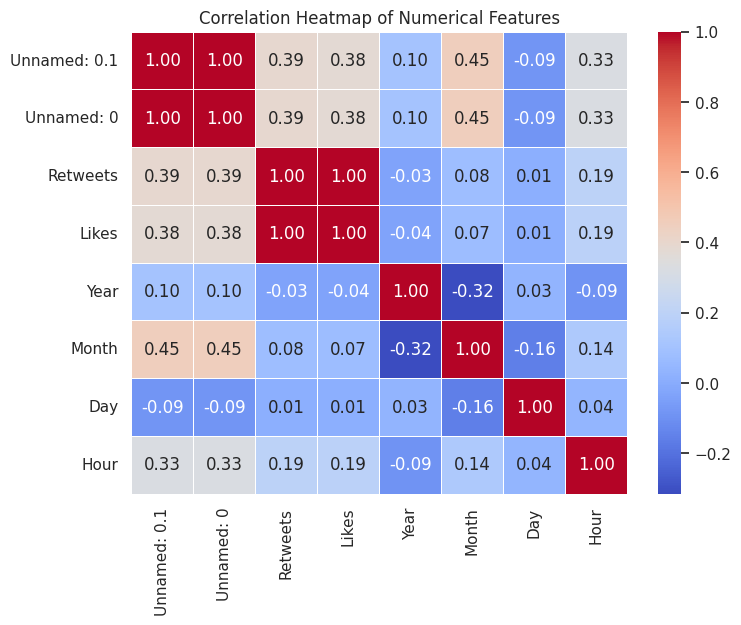

In [88]:
# Visualizing  the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# PROJECT 1 TASK 3

/tmp/ipykernel_787/2824873810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment', data=df, palette='viridis')


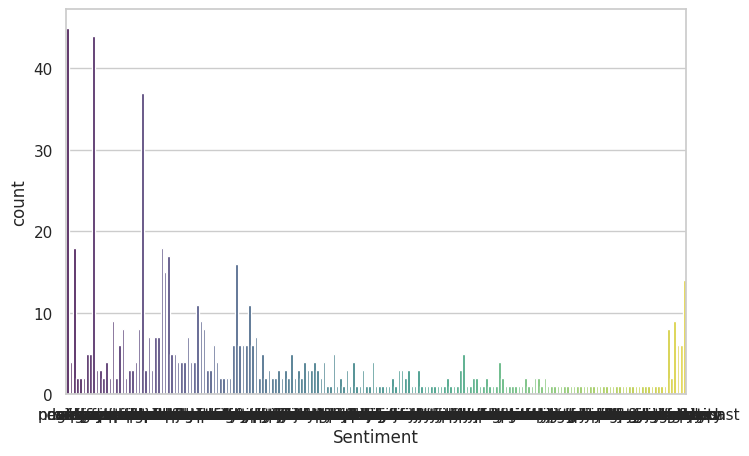

In [89]:
#  BAR PLOT showing Sentiment Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Sentiment', data=df, palette='viridis')

Text(0, 0.5, 'Count / Frequency')

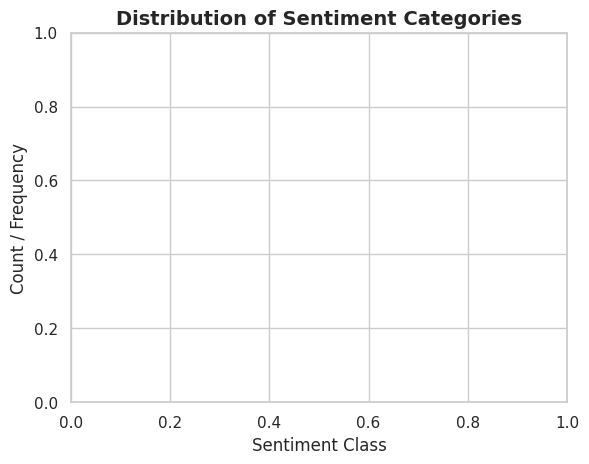

In [90]:
# Customizing the  titles, labels, and legends
plt.title(
    'Distribution of Sentiment Categories', fontsize=14, fontweight='bold'
)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Count / Frequency', fontsize=12)

In [91]:
# Adding value annotations on top of the bars for report clarity
for p in ax.patches:
  ax.annotate(
      f'{int(p.get_height())}',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 5),
      textcoords='offset points',
  )

plt.tight_layout()
# Export plot as image
plt.savefig('sentiment_barplot.png', dpi=300)
print("Saved 'sentiment_barplot.png'")
plt.show()

Saved 'sentiment_barplot.png'


<Figure size 640x480 with 0 Axes>

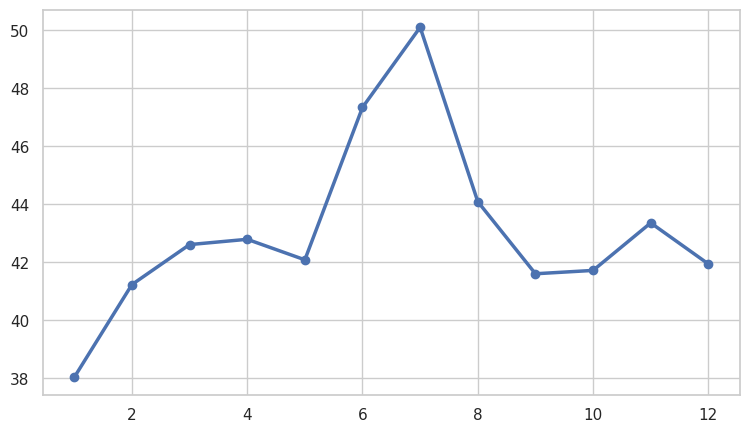

In [92]:
# LINE CHART showing the Activity / Likes Trend over Time (Months)
# Grouping data by Month to show a trend line
monthly_trend = df.groupby('Month')['Likes'].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(
    monthly_trend['Month'],
    monthly_trend['Likes'],
    marker='o',
    color='b',
    linewidth=2.5,
    label='Average Likes',
)

/tmp/ipykernel_787/1786546182.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', frameon=True)


Saved 'likes_trend_linechart.png'


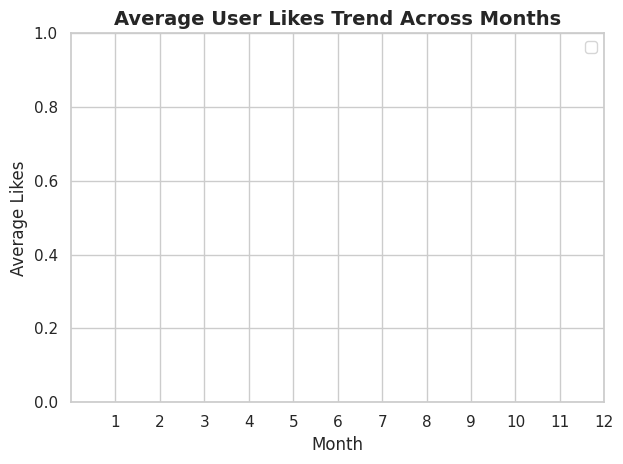

In [93]:
# Customize titles and labels
plt.title(
    'Average User Likes Trend Across Months', fontsize=14, fontweight='bold'
)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Likes', fontsize=12)
plt.xticks(monthly_trend['Month'])  # Ensure all months show clearly
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
# Export plot as image
plt.savefig('likes_trend_linechart.png', dpi=300)
print("Saved 'likes_trend_linechart.png'")
plt.show()

<Axes: xlabel='Retweets', ylabel='Likes'>

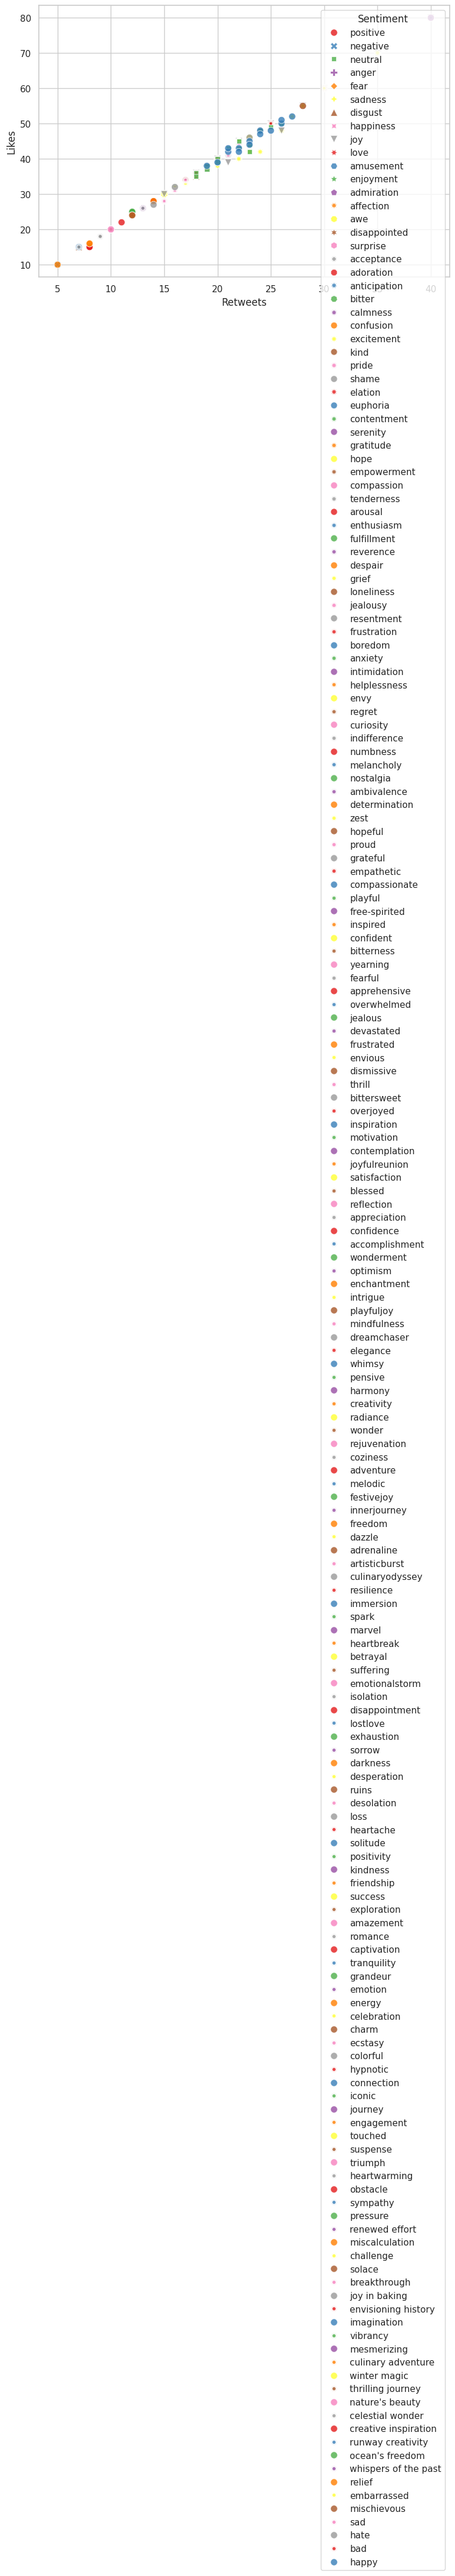

In [94]:
# SCATTER PLOT showing Retweets vs. Likes by Platform/Sentiment
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Retweets',
    y='Likes',
    hue='Sentiment',
    style='Sentiment',
    data=df,
    s=70,
    alpha=0.8,
    palette='Set1',
)

/tmp/ipykernel_787/1104730113.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Sentiment Class', bbox_to_anchor=(1.05, 1), loc='upper left')


Saved 'retweets_vs_likes_scatterplot.png'


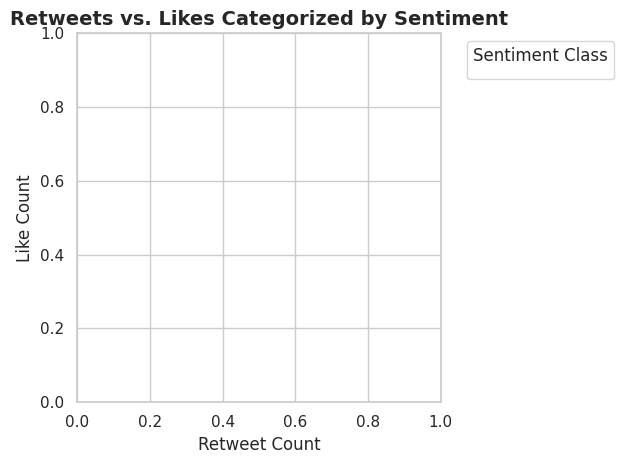

In [95]:
# Customize titles, labels, and legends
plt.title('Retweets vs. Likes Categorized by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Retweet Count', fontsize=12)
plt.ylabel('Like Count', fontsize=12)
plt.legend(title='Sentiment Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
# Export plot as image
plt.savefig('retweets_vs_likes_scatterplot.png', dpi=300)
print("Saved 'retweets_vs_likes_scatterplot.png'")
plt.show()

**PROJECT TWO: TASK 1**

In [96]:
print('--- Initial Data Preview ---')
print(df[['Retweets', 'Likes']].head())

--- Initial Data Preview ---
   Retweets  Likes
0      15.0   30.0
1       5.0   10.0
2      20.0   40.0
3       8.0   15.0
4      12.0   25.0


In [97]:
# 2. Define your Features (X) and Target (y)
# Predict 'Likes' based on 'Retweets'
X = df[['Retweets']]
y = df['Likes']

In [98]:
# 3. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [99]:
print(f'\nTraining set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')


Training set shape: (565, 1)
Testing set shape: (142, 1)


In [100]:
# 4. Fit a linear regression model using scikit-learn
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [101]:
# 5. Interpret the coefficients
print('\n--- Model Coefficients ---')
print(f'Intercept (Beta 0): {model.intercept_:.4f}')
print(f'Coefficient / Slope (Beta 1): {model.coef_[0]:.4f}')
print(
    'Interpretation: For every 1 unit increase in Retweets, Likes are predicted'
    f' to change by {model.coef_[0]:.4f} units.'
)


--- Model Coefficients ---
Intercept (Beta 0): 0.0740
Coefficient / Slope (Beta 1): 1.9916
Interpretation: For every 1 unit increase in Retweets, Likes are predicted to change by 1.9916 units.


In [102]:
# 6. Make predictions on the testing set
y_pred = model.predict(X_test)

In [103]:
# 7. Evaluate the model using R-squared and Mean Squared Error (MSE)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [104]:
print('\n--- Model Evaluation Metrics ---')
print(f'R-squared ($R^2$): {r2:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')


--- Model Evaluation Metrics ---
R-squared ($R^2$): 0.9966
Mean Squared Error (MSE): 0.6824


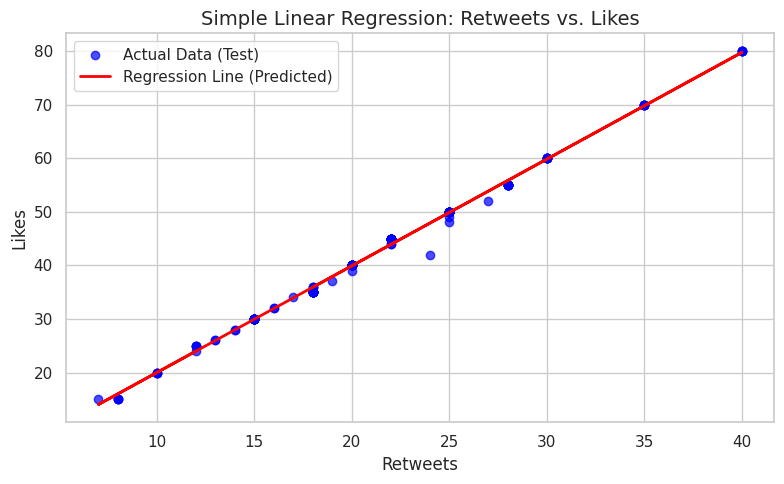

In [105]:
# 8. Visualize the regression line against the test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Data (Test)')
plt.plot(
    X_test,
    y_pred,
    color='red',
    linewidth=2,
    label='Regression Line (Predicted)',
)
plt.title('Simple Linear Regression: Retweets vs. Likes', fontsize=14)
plt.xlabel('Retweets', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=300)
plt.show()

# PROJECT 2: TASK 2

In [106]:
# Ensuring the Timestamp column is converted to datetime format and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')
# Resample and aggregate data by day (e.g., average Likes per day)
ts_df = df.set_index('Timestamp').resample('D')['Likes'].mean().ffill()
print('--- Time Series Head ---')
print(ts_df.head())


--- Time Series Head ---
Timestamp
2010-05-15    40.0
2010-05-16    40.0
2010-05-17    40.0
2010-05-18    40.0
2010-05-19    40.0
Freq: D, Name: Likes, dtype: float64


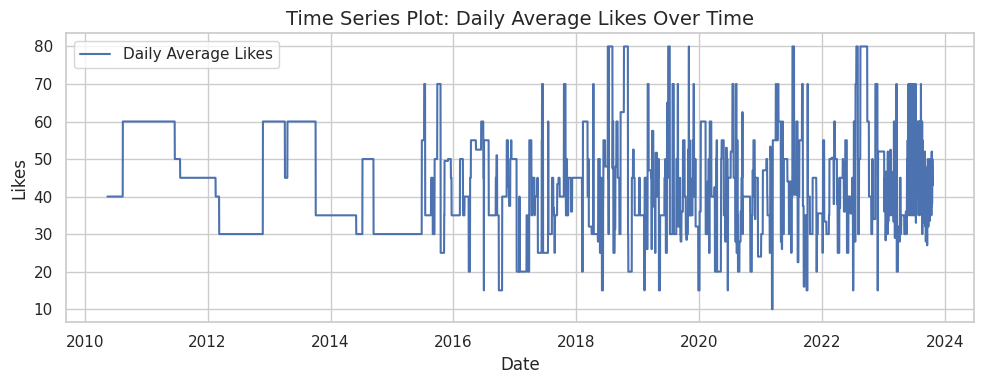

In [107]:
# 2. Ploting time-series data and identify patterns
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df.values, color='b', label='Daily Average Likes')
plt.title('Time Series Plot: Daily Average Likes Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('timeseries_plot.png', dpi=300)
plt.show()

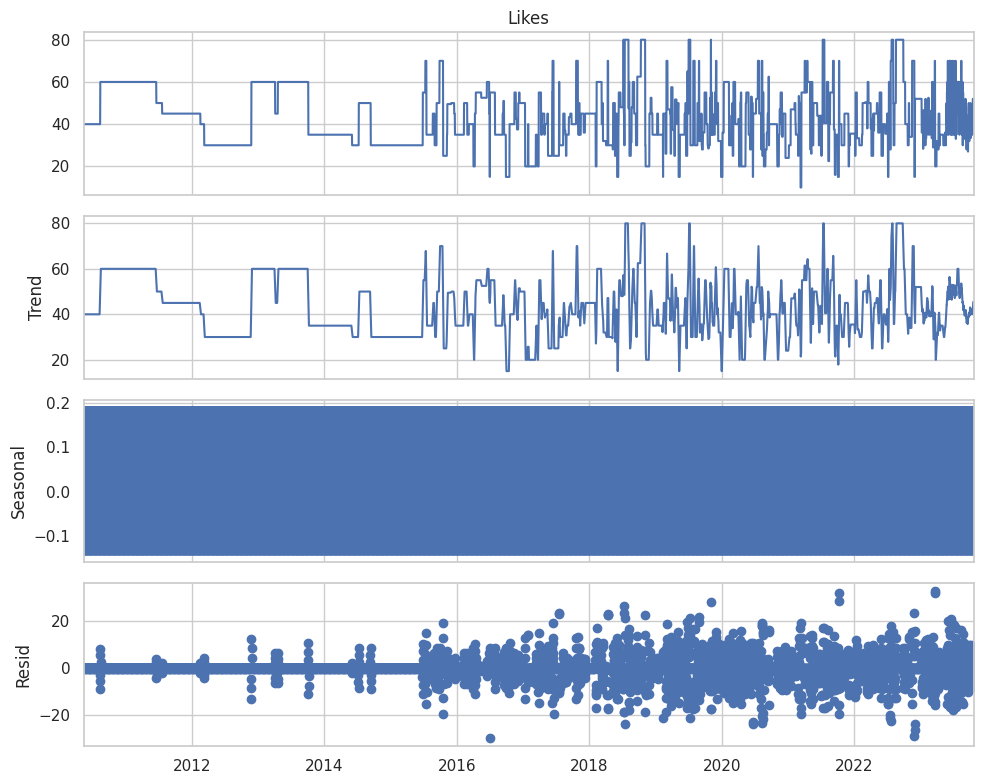

In [108]:
# 3. Decomposeing the series into trend, seasonality, and residuals using statsmodels
decomposition = seasonal_decompose(ts_df, model='additive', period=7)
# Plot the decomposition components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig('timeseries_decomposition.png', dpi=300)
plt.show()

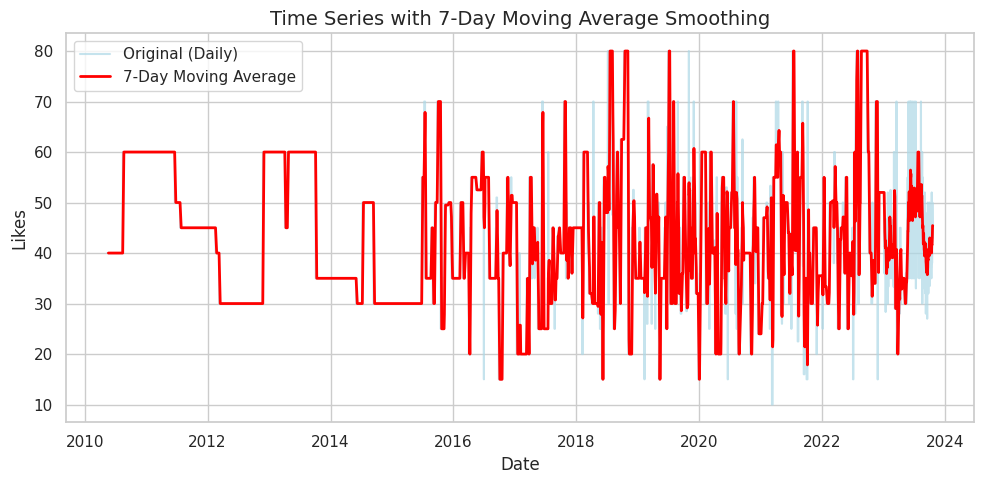

In [109]:
# 4. Performing moving average smoothing and plot the results
rolling_avg = ts_df.rolling(window=7).mean()

plt.figure(figsize=(10, 5))
plt.plot(ts_df.index, ts_df.values, color='lightblue', label='Original (Daily)', alpha=0.7)
plt.plot(ts_df.index, rolling_avg.values, color='red', linewidth=2, label='7-Day Moving Average')
plt.title('Time Series with 7-Day Moving Average Smoothing', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('moving_average_plot.png', dpi=300)
plt.show()

# project 2 : Task 3

In [110]:
# Selecting numerical features for clustering (e.g., Retweets and Likes)
X = df[['Retweets', 'Likes']]
#Standardizing the dataset using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [111]:
# Determining the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

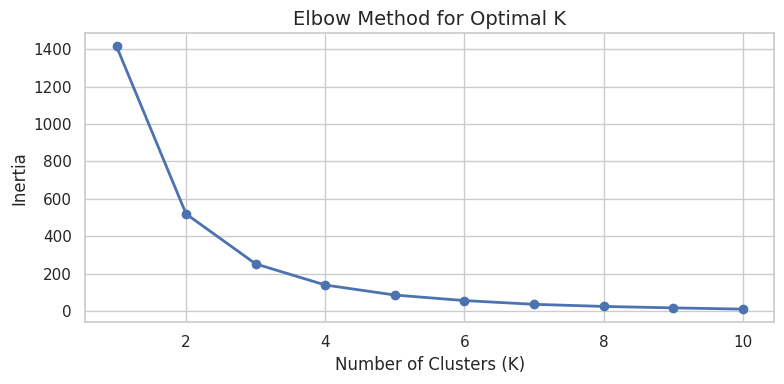

In [112]:
# Ploting the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='b', linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.tight_layout()
plt.savefig('elbow_method_plot.png', dpi=300)
plt.show()

In [113]:
# Applying K-Means clustering with the optimal K ( using K=3 as an example based on the elbow curve)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'\n--- Clustering Complete with K={optimal_k} ---')
print(df['Cluster'].value_counts())


--- Clustering Complete with K=3 ---
Cluster
2    282
0    265
1    160
Name: count, dtype: int64


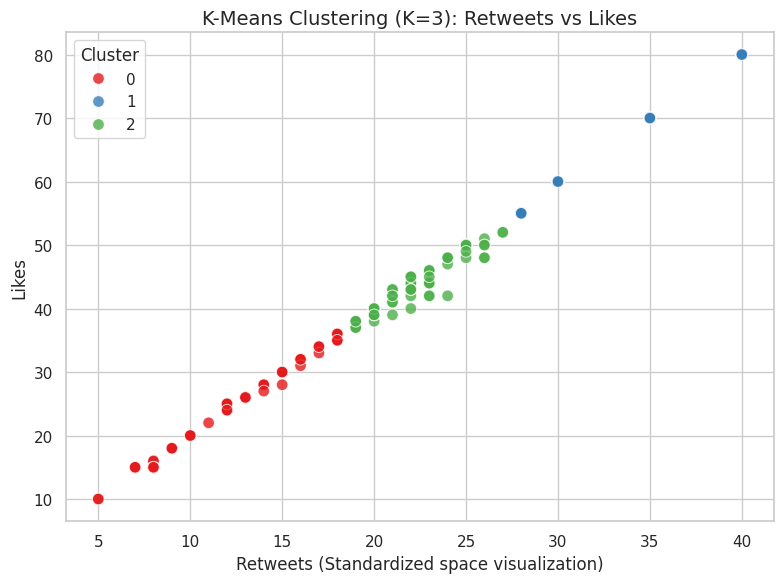

In [114]:
# Visualizing clusters using 2D scatter plots
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Retweets',
    y='Likes',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=70,
    alpha=0.8,
)
plt.title(f'K-Means Clustering (K={optimal_k}): Retweets vs Likes', fontsize=14)
plt.xlabel('Retweets (Standardized space visualization)', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.legend(title='Cluster', loc='upper left')
plt.tight_layout()
plt.savefig('kmeans_clusters_plot.png', dpi=300)
plt.show()

In [115]:
# 1. Load your dataset
df = pd.read_csv('cleaned_sentiment_data.csv')

print('--- Initial Data Preview ---')
print(df.head())

# 2. Preprocess the data
# For classification, let's predict 'Sentiment' (e.g., Positive vs Negative/Neutral or multi-class)
# Select features and target variable
X = df[['Retweets', 'Likes']]  # Numerical features as an example
y = df['Sentiment']  # Categorical target variable

# Handle categorical variables if needed (e.g., one-hot encoding if using other text/categorical features)
# X = pd.get_dummies(X, drop_first=True)

# Split into training (80%) and testing (20%) sets
# Check value counts for y to identify single-member classes if the error persists
# print(y.value_counts())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # removed stratify=y to prevent error with single-instance classes
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train and test multiple classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

evaluation_results = {}

print('\n--- Model Evaluation Results ---')
for name, model in models.items():
  # Train the model
  model.fit(X_train_scaled, y_train)
  # Predict on test data
  y_pred = model.predict(X_test_scaled)

  # Calculate evaluation metrics
  acc = accuracy_score(y_test, y_pred)
  # Added error handling for precision, recall, f1-score when a class might be missing in y_pred
  # This is a good practice, especially after removing stratification
  try:
      prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
      rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
      f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
  except ValueError:
      print(f"Could not calculate weighted metrics for {name} due to missing classes in prediction.")
      prec = rec = f1 = float('nan') # Assign NaN or other indicator if calculation fails

  evaluation_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

  print(f'\nModel: {name}')
  print(f'  Accuracy:  {acc:.4f}')
  print(f'  Precision: {prec:.4f}')
  print(f'  Recall:    {rec:.4f}')
  print(f'  F1-Score:  {f1:.4f}')

# 4. Perform hyperparameter tuning using Grid Search (Example using Random Forest)
print('\n--- Performing Hyperparameter Tuning for Random Forest ---')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
)
grid_search.fit(X_train_scaled, y_train)

print(f'Best Hyperparameters: {grid_search.best_params_}')
print(f'Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}')

# Evaluate tuned model on test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f'Tuned Random Forest Test Accuracy: {tuned_acc:.4f}')

--- Initial Data Preview ---
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text Sentiment  \
0   Enjoying a beautiful day at the park!        ...  positive   
1   Traffic was terrible this morning.           ...  negative   
2   Just finished an amazing workout! 💪          ...  positive   
3   Excited about the upcoming weekend getaway!  ...  positive   
4   Trying out a new recipe for dinner tonight.  ...   neutral   

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets 

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Hyperparameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.1009
Tuned Random Forest Test Accuracy: 0.0845


# **PROJECT 3: TASK 1**

In [116]:
print (">>> initial Data Preview <<<")
print(df.head())

>>> initial Data Preview <<<
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text Sentiment  \
0   Enjoying a beautiful day at the park!        ...  positive   
1   Traffic was terrible this morning.           ...  negative   
2   Just finished an amazing workout! 💪          ...  positive   
3   Excited about the upcoming weekend getaway!  ...  positive   
4   Trying out a new recipe for dinner tonight.  ...   neutral   

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets 

In [117]:
# 2. Preprocess the data
x = df[['Retweets', 'Likes']]  # numerical features as an example
y = df['Sentiment']  # categorical target variable

# splitting the df into training and testing
# stratify=y is removed because some sentiment classes have only 1 member
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# feature scaling using StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [118]:
# 3. Train and test multiple classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

evaluation_results = {}

print('\n--- Model Evaluation Results ---')
for name, model in models.items():
  # Train the model using lowercase x_train_s
  model.fit(x_train_s, y_train)
  # Predict on test data using lowercase x_test_s
  y_pred = model.predict(x_test_s)

  # Calculate evaluation metrics
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
  rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
  f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

  evaluation_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

  print(f'\nModel: {name}')
  print(f'  Accuracy:  {acc:.4f}')
  print(f'  Precision: {prec:.4f}')
  print(f'  Recall:    {rec:.4f}')
  print(f'  F1-Score:  {f1:.4f}')

# 4. Perform hyperparameter tuning using Grid Search (Example using Random Forest)
print('\n--- Performing Hyperparameter Tuning for Random Forest ---')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
)
grid_search.fit(x_train_s, y_train)

print(f'Best Hyperparameters: {grid_search.best_params_}')
print(f'Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}')

# Evaluate tuned model on test set using lowercase x_test_s
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(x_test_s)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f'Tuned Random Forest Test Accuracy: {tuned_acc:.4f}')


--- Model Evaluation Results ---

Model: Logistic Regression
  Accuracy:  0.0915
  Precision: 0.0140
  Recall:    0.0915
  F1-Score:  0.0242

Model: Decision Tree
  Accuracy:  0.0986
  Precision: 0.0320
  Recall:    0.0986
  F1-Score:  0.0460

Model: Random Forest
  Accuracy:  0.1056
  Precision: 0.0476
  Recall:    0.1056
  F1-Score:  0.0584

--- Performing Hyperparameter Tuning for Random Forest ---


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Hyperparameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.1009
Tuned Random Forest Test Accuracy: 0.0845


In [119]:
from google.colab import files

# Download the cleaned dataset to your local computer
files.download('cleaned_sentiment_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**TASK 2**: IN POWERBI PDF

**TASK 3**

In [120]:
#Downloading required NLTK resources
print (">>> DOWNLOADING REQUIRED NLTK RESOURCES <<<")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

>>> DOWNLOADING REQUIRED NLTK RESOURCES <<<


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [121]:
# 1. Load your dataset (replace with your file path, e.g., pd.read_csv('cleaned_sentiment_data.csv'))
data = {
    'text': [
        "I absolutely love this product, it's amazing and exceeded my expectations!",
        "Terrible customer service, very disappointed and frustrating.",
        "The item is okay, nothing special really, serves its basic purpose.",
        "Fantastic experience, highly recommend to everyone looking for quality!",
        "Worst purchase ever, completely useless and broke immediately."
    ]
}
df = pd.DataFrame(data)

In [122]:
# 2. Text Preprocessing (Tokenization, Stopwords Removal, & Lemmatization)
# Download the missing punkt_tab package required by word_tokenize
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase and tokenize
    tokens = word_tokenize(str(text).lower())
    # Remove punctuation/non-alphabetic tokens and stop words, then lemmatize
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word.isalnum() and word not in stop_words]
    return " ".join(cleaned)

df['cleaned_text'] = df['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [123]:
# 3. Sentiment Analysis using TextBlob
def classify_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['cleaned_text'].apply(classify_sentiment)

# Display classification preview
print(df[['text', 'sentiment']])

                                                text sentiment
0  I absolutely love this product, it's amazing a...  Positive
1  Terrible customer service, very disappointed a...  Negative
2  The item is okay, nothing special really, serv...  Positive
3  Fantastic experience, highly recommend to ever...  Positive
4  Worst purchase ever, completely useless and br...  Negative


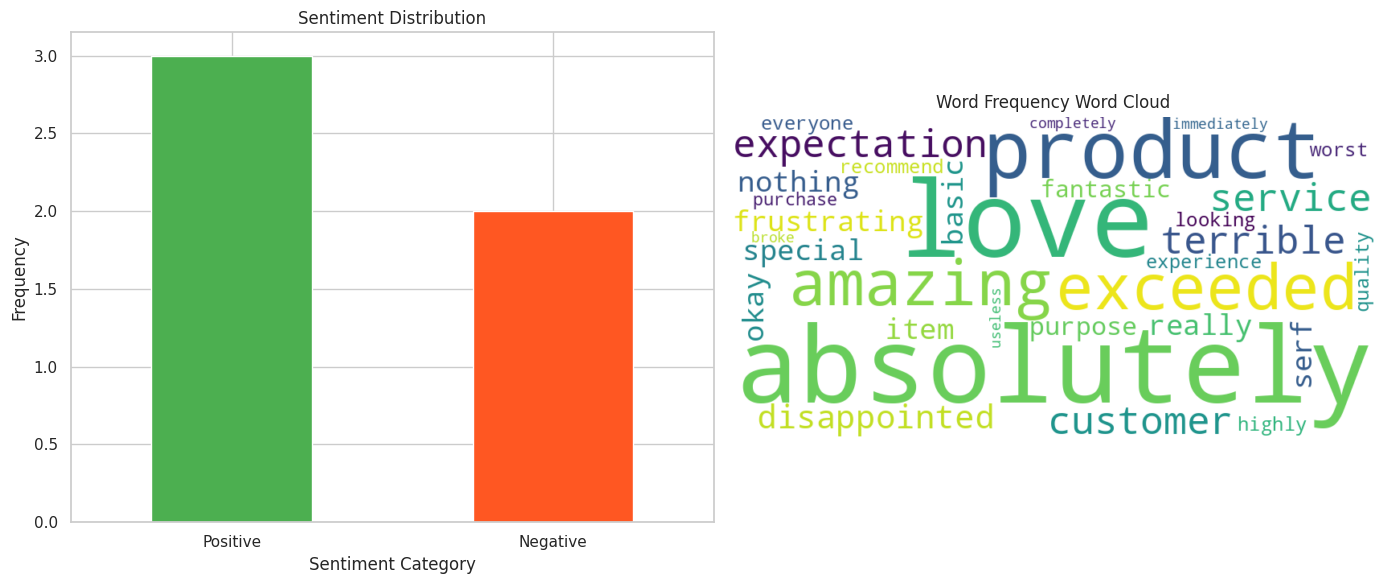

In [124]:
# 4. Visualizations (Sentiment Distribution & Word Cloud)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sentiment Distribution Bar Chart
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#FF5722', '#2196F3'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)

# Word Cloud for Frequent Terms
all_words = ' '.join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_words)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Frequency Word Cloud')

plt.tight_layout()
plt.show()